# PHM Challenge 2010 Milling Dataset - Complete Data Exploration
## Your Journey to Becoming a Data Expert

**Dataset**: PHM Challenge 2010 - Milling Machine Tool Wear Prediction

**Goal**: Understand every aspect of the data for publication-quality research

---

## Step 1: Environment Setup
First, let's import all necessary libraries and set up our environment

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import os
import glob
from pathlib import Path

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Statistical analysis
from scipy import stats
from scipy.signal import welch, butter, filtfilt

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.float_format', '{:.6f}'.format)

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")

✓ All libraries imported successfully!
NumPy version: 2.2.6
Pandas version: 2.3.1


## Step 2: Dataset Path Configuration
Set the path to your PHM Challenge 2010 dataset

In [2]:
# IMPORTANT: Update this path to your actual dataset location
DATA_PATH = r"E:\Collaboration Work\With Farooq\phm dataset\PHM Challange 2010 Milling"

# Check if path exists
if os.path.exists(DATA_PATH):
    print(f"✓ Dataset path found: {DATA_PATH}")
    print(f"\nDirectory contents:")
    for item in os.listdir(DATA_PATH):
        full_path = os.path.join(DATA_PATH, item)
        if os.path.isdir(full_path):
            print(f"  📁 {item}/")
        else:
            size = os.path.getsize(full_path) / (1024*1024)  # Size in MB
            print(f"  📄 {item} ({size:.2f} MB)")
else:
    print(f"✗ Path not found: {DATA_PATH}")
    print("Please update DATA_PATH variable with the correct path")

✓ Dataset path found: E:\Collaboration Work\With Farooq\phm dataset\PHM Challange 2010 Milling

Directory contents:
  📁 c1/
  📁 c2/
  📁 c3/
  📁 c4/
  📁 c5/
  📁 c6/
  📄 c_1.mat (1233.81 MB)
  📄 c_2.mat (1253.10 MB)
  📄 c_3.mat (1232.41 MB)
  📄 c_4.mat (1248.15 MB)
  📄 c_5.mat (1256.66 MB)
  📄 c_6.mat (1259.15 MB)


## Step 3: Understanding the Dataset Structure

### Background: PHM 2010 Challenge
- **Problem**: Predict tool wear in CNC milling machines
- **Data Type**: Time-series sensor data from milling operations
- **Goal**: Predict remaining useful life (RUL) or tool condition

Let's explore the complete structure

In [3]:
def explore_directory_structure(path, max_depth=3, current_depth=0, prefix=""):
    """
    Recursively explore directory structure
    """
    if current_depth >= max_depth:
        return
    
    try:
        items = sorted(os.listdir(path))
        for i, item in enumerate(items):
            full_path = os.path.join(path, item)
            is_last = (i == len(items) - 1)
            
            if os.path.isdir(full_path):
                connector = "└── " if is_last else "├── "
                print(f"{prefix}{connector}📁 {item}/")
                extension = "    " if is_last else "│   "
                explore_directory_structure(full_path, max_depth, current_depth + 1, prefix + extension)
            else:
                connector = "└── " if is_last else "├── "
                size = os.path.getsize(full_path) / 1024  # Size in KB
                print(f"{prefix}{connector}📄 {item} ({size:.1f} KB)")
    except PermissionError:
        print(f"{prefix}✗ Permission denied")

print("Complete Directory Structure:")
print("="*80)
explore_directory_structure(DATA_PATH, max_depth=4)

Complete Directory Structure:
├── 📁 c1/
│   ├── 📁 c1/
│   │   ├── 📄 c_1_001.csv (5401.0 KB)
│   │   ├── 📄 c_1_001.win49.npz (10.8 KB)
│   │   ├── 📄 c_1_002.csv (9297.2 KB)
│   │   ├── 📄 c_1_002.win49.npz (16.9 KB)
│   │   ├── 📄 c_1_003.csv (9323.0 KB)
│   │   ├── 📄 c_1_003.win49.npz (16.9 KB)
│   │   ├── 📄 c_1_004.csv (9334.0 KB)
│   │   ├── 📄 c_1_004.win49.npz (16.9 KB)
│   │   ├── 📄 c_1_005.csv (9305.2 KB)
│   │   ├── 📄 c_1_005.win49.npz (16.9 KB)
│   │   ├── 📄 c_1_006.csv (9389.4 KB)
│   │   ├── 📄 c_1_006.win49.npz (17.0 KB)
│   │   ├── 📄 c_1_007.csv (9396.0 KB)
│   │   ├── 📄 c_1_007.win49.npz (17.0 KB)
│   │   ├── 📄 c_1_008.csv (9372.9 KB)
│   │   ├── 📄 c_1_008.win49.npz (17.0 KB)
│   │   ├── 📄 c_1_009.csv (9327.5 KB)
│   │   ├── 📄 c_1_009.win49.npz (16.9 KB)
│   │   ├── 📄 c_1_010.csv (9360.9 KB)
│   │   ├── 📄 c_1_010.win49.npz (16.9 KB)
│   │   ├── 📄 c_1_011.csv (9365.2 KB)
│   │   ├── 📄 c_1_011.win49.npz (16.9 KB)
│   │   ├── 📄 c_1_012.csv (9355.6 KB)
│   │   ├── 📄 c_1_012.win49.

## Step 4: Identify All Data Files
Find all CSV, TXT, or data files in the dataset

In [4]:
# Find all potential data files
file_extensions = ['*.csv', '*.txt', '*.dat', '*.xls*', '*.mat']
all_files = []

for ext in file_extensions:
    files = glob.glob(os.path.join(DATA_PATH, '**', ext), recursive=True)
    all_files.extend(files)

print(f"Total files found: {len(all_files)}\n")

# Organize by type
file_info = []
for filepath in all_files:
    rel_path = os.path.relpath(filepath, DATA_PATH)
    size = os.path.getsize(filepath) / (1024*1024)  # MB
    ext = os.path.splitext(filepath)[1]
    file_info.append({
        'File': os.path.basename(filepath),
        'Relative Path': rel_path,
        'Extension': ext,
        'Size (MB)': round(size, 2)
    })

file_df = pd.DataFrame(file_info)
if len(file_df) > 0:
    file_df = file_df.sort_values(['Extension', 'Size (MB)'], ascending=[True, False])
    print(file_df.to_string(index=False))
    
    print("\n" + "="*80)
    print("Summary by file type:")
    print(file_df.groupby('Extension').agg({
        'File': 'count',
        'Size (MB)': 'sum'
    }).rename(columns={'File': 'Count'}))
else:
    print("No data files found. Please check the path.")

Total files found: 1899

       File     Relative Path Extension   Size (MB)
c_1_305.csv c1\c1\c_1_305.csv      .csv   11.170000
c_1_309.csv c1\c1\c_1_309.csv      .csv   11.160000
c_1_315.csv c1\c1\c_1_315.csv      .csv   11.050000
c_5_253.csv c5\c5\c_5_253.csv      .csv   10.220000
c_1_308.csv c1\c1\c_1_308.csv      .csv   10.150000
c_1_304.csv c1\c1\c_1_304.csv      .csv   10.070000
c_4_265.csv c4\c4\c_4_265.csv      .csv   10.070000
c_4_293.csv c4\c4\c_4_293.csv      .csv   10.070000
c_5_286.csv c5\c5\c_5_286.csv      .csv    9.970000
c_4_198.csv c4\c4\c_4_198.csv      .csv    9.920000
c_1_290.csv c1\c1\c_1_290.csv      .csv    9.880000
c_1_291.csv c1\c1\c_1_291.csv      .csv    9.870000
c_4_225.csv c4\c4\c_4_225.csv      .csv    9.860000
c_4_299.csv c4\c4\c_4_299.csv      .csv    9.860000
c_4_302.csv c4\c4\c_4_302.csv      .csv    9.860000
c_4_291.csv c4\c4\c_4_291.csv      .csv    9.850000
c_4_292.csv c4\c4\c_4_292.csv      .csv    9.850000
c_4_294.csv c4\c4\c_4_294.csv      .csv

## Step 5: Load and Inspect First Data File
Let's load the first file to understand the data format

In [5]:
# Function to intelligently load data files
def load_data_file(filepath, nrows=10):
    """
    Try different methods to load a data file
    """
    print(f"Loading: {os.path.basename(filepath)}")
    print(f"Full path: {filepath}")
    print(f"File size: {os.path.getsize(filepath)/(1024*1024):.2f} MB\n")
    
    # Try different delimiters
    delimiters = [',', '\t', ' ', ';', '|']
    
    for delim in delimiters:
        try:
            df = pd.read_csv(filepath, delimiter=delim, nrows=nrows, engine='python')
            if df.shape[1] > 1:  # Successfully parsed multiple columns
                print(f"✓ Successfully loaded with delimiter: '{delim}'")
                return df, delim
        except Exception as e:
            continue
    
    # If all fail, try reading as text
    try:
        with open(filepath, 'r') as f:
            lines = [f.readline() for _ in range(min(nrows, 20))]
        print("Could not parse as CSV. Showing raw content:")
        print("\n".join(lines))
        return None, None
    except Exception as e:
        print(f"Error reading file: {e}")
        return None, None

# Load first file as sample
if len(all_files) > 0:
    sample_file = all_files[0]
    df_sample, delimiter = load_data_file(sample_file, nrows=10)
    
    if df_sample is not None:
        print("\n" + "="*80)
        print("SAMPLE DATA (First 10 rows):")
        print("="*80)
        print(df_sample)
        
        print("\n" + "="*80)
        print("DATA INFO:")
        print("="*80)
        print(f"Shape: {df_sample.shape}")
        print(f"Columns: {list(df_sample.columns)}")
        print(f"\nData types:")
        print(df_sample.dtypes)

Loading: c1_wear.csv
Full path: E:\Collaboration Work\With Farooq\phm dataset\PHM Challange 2010 Milling\c1\c1_wear.csv
File size: 0.01 MB

✓ Successfully loaded with delimiter: ','

SAMPLE DATA (First 10 rows):
   cut   flute_1   flute_2   flute_3
0    1 32.317114 48.892617 37.720825
1    2 37.914879 49.570815 37.720825
2    3 43.087910 50.302867 37.720825
3    4 47.859072 51.083652 37.849851
4    5 52.250329 51.908288 38.172665
5    6 56.282766 52.772127 38.617556
6    7 59.976616 53.670745 39.174556
7    8 63.351288 54.599939 39.834155
8    9 66.425391 55.555716 40.587292
9   10 69.216757 56.534286 41.425337

DATA INFO:
Shape: (10, 4)
Columns: ['cut', 'flute_1', 'flute_2', 'flute_3']

Data types:
cut          int64
flute_1    float64
flute_2    float64
flute_3    float64
dtype: object


## Step 6: Deep Dive - Load Complete Dataset
Now let's load ALL the data to understand the complete picture

In [6]:
# Load all data files
def load_all_dataset_files(file_list, delimiter=None):
    """
    Load all files and organize them
    """
    datasets = {}
    
    for filepath in file_list:
        filename = os.path.basename(filepath)
        print(f"Loading {filename}...", end=" ")
        
        try:
            # Auto-detect delimiter if not provided
            if delimiter is None:
                df, delim = load_data_file(filepath, nrows=5)
                if df is not None:
                    df_full = pd.read_csv(filepath, delimiter=delim, engine='python')
                else:
                    continue
            else:
                df_full = pd.read_csv(filepath, delimiter=delimiter)
            
            datasets[filename] = df_full
            print(f"✓ Shape: {df_full.shape}")
            
        except Exception as e:
            print(f"✗ Error: {str(e)[:50]}")
    
    return datasets

# Load all files
print("Loading all dataset files...")
print("="*80)
all_datasets = load_all_dataset_files(all_files)

print("\n" + "="*80)
print(f"Successfully loaded {len(all_datasets)} files")
print("="*80)

Loading all dataset files...
Loading c1_wear.csv... Loading: c1_wear.csv
Full path: E:\Collaboration Work\With Farooq\phm dataset\PHM Challange 2010 Milling\c1\c1_wear.csv
File size: 0.01 MB

✓ Successfully loaded with delimiter: ','
✓ Shape: (315, 4)
Loading c_1_001.csv... Loading: c_1_001.csv
Full path: E:\Collaboration Work\With Farooq\phm dataset\PHM Challange 2010 Milling\c1\c1\c_1_001.csv
File size: 5.27 MB

✓ Successfully loaded with delimiter: ','
✓ Shape: (127398, 7)
Loading c_1_002.csv... Loading: c_1_002.csv
Full path: E:\Collaboration Work\With Farooq\phm dataset\PHM Challange 2010 Milling\c1\c1\c_1_002.csv
File size: 9.08 MB

✓ Successfully loaded with delimiter: ','
✓ Shape: (217294, 7)
Loading c_1_003.csv... Loading: c_1_003.csv
Full path: E:\Collaboration Work\With Farooq\phm dataset\PHM Challange 2010 Milling\c1\c1\c_1_003.csv
File size: 9.10 MB

✓ Successfully loaded with delimiter: ','
✓ Shape: (218387, 7)
Loading c_1_004.csv... Loading: c_1_004.csv
Full path: E:\Col

## Step 7: Comprehensive Dataset Summary
Get a complete overview of all loaded data

In [7]:
# Create comprehensive summary
summary_data = []

for filename, df in all_datasets.items():
    summary_data.append({
        'File Name': filename,
        'Rows': df.shape[0],
        'Columns': df.shape[1],
        'Column Names': ', '.join(df.columns.astype(str)[:5]) + ('...' if len(df.columns) > 5 else ''),
        'Memory (MB)': round(df.memory_usage(deep=True).sum() / (1024*1024), 2),
        'Has Missing': df.isnull().any().any(),
        'Missing %': round(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 2)
    })

summary_df = pd.DataFrame(summary_data)
print("COMPLETE DATASET SUMMARY")
print("="*80)
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("TOTAL STATISTICS")
print("="*80)
print(f"Total rows across all files: {summary_df['Rows'].sum():,}")
print(f"Total memory usage: {summary_df['Memory (MB)'].sum():.2f} MB")
print(f"Files with missing data: {summary_df['Has Missing'].sum()}")

COMPLETE DATASET SUMMARY
  File Name   Rows  Columns                                Column Names  Memory (MB)  Has Missing  Missing %
c1_wear.csv    315        4              cut, flute_1, flute_2, flute_3     0.010000        False   0.000000
c_1_001.csv 127398        7      0.704, -0.387, -1.084, 0.018, 0.031...     6.800000        False   0.000000
c_1_002.csv 217294        7      -0.1, -1.397, 1.541, -0.077, -0.097...    11.600000        False   0.000000
c_1_003.csv 218387        7      0.187, 2.05, -1.026, -0.103, -0.116...    11.660000        False   0.000000
c_1_004.csv 218735        7     -0.416, -1.037, 0.359, 0.006, -0.012...    11.680000        False   0.000000
c_1_005.csv 219496        7    -0.466, -0.366, 1.136, -0.001, -0.008...    11.720000        False   0.000000
c_1_006.csv 218845        7      0.113, 1.749, 0.985, 0.113.1, 0.088...    11.690000        False   0.000000
c_1_007.csv 219025        7        0.008, 0.78, 0.124, 0.009, -0.013...    11.700000        False   0.0

## Step 8: Detailed Column Analysis
Understand each column in detail

In [8]:
# Analyze each dataset in detail
for filename, df in all_datasets.items():
    print("\n" + "="*80)
    print(f"DETAILED ANALYSIS: {filename}")
    print("="*80)
    
    print(f"\nShape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    
    print("\nColumn Information:")
    print("-" * 80)
    
    col_info = []
    for col in df.columns:
        col_info.append({
            'Column': col,
            'Type': df[col].dtype,
            'Non-Null': df[col].count(),
            'Null': df[col].isnull().sum(),
            'Null %': round(df[col].isnull().sum() / len(df) * 100, 2),
            'Unique': df[col].nunique(),
            'Sample Values': str(df[col].dropna().head(3).tolist())[:50]
        })
    
    col_df = pd.DataFrame(col_info)
    print(col_df.to_string(index=False))
    
    # Statistical summary for numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print("\nStatistical Summary (Numeric Columns):")
        print("-" * 80)
        print(df[numeric_cols].describe().T)


DETAILED ANALYSIS: c1_wear.csv

Shape: 315 rows × 4 columns

Column Information:
--------------------------------------------------------------------------------
 Column    Type  Non-Null  Null   Null %  Unique                           Sample Values
    cut   int64       315     0 0.000000     315                               [1, 2, 3]
flute_1 float64       315     0 0.000000     242   [32.31711361, 37.914879, 43.08790971]
flute_2 float64       315     0 0.000000     256 [48.89261732, 49.57081504, 50.30286727]
flute_3 float64       315     0 0.000000     266 [37.72082548, 37.72082548, 37.72082548]

Statistical Summary (Numeric Columns):
--------------------------------------------------------------------------------
             count       mean       std       min       25%        50%  \
cut     315.000000 158.000000 91.076891  1.000000 79.500000 158.000000   
flute_1 315.000000 110.002058 28.540942 32.317114 87.390901 102.141075   
flute_2 315.000000 107.517470 25.760210 48.892617

## Step 9: Data Quality Assessment
Check for data quality issues

In [9]:
def assess_data_quality(df, dataset_name):
    """
    Comprehensive data quality assessment
    """
    print(f"\nDATA QUALITY REPORT: {dataset_name}")
    print("="*80)
    
    # 1. Missing values
    missing = df.isnull().sum()
    if missing.sum() > 0:
        print("\n1. MISSING VALUES:")
        missing_df = pd.DataFrame({
            'Column': missing[missing > 0].index,
            'Missing Count': missing[missing > 0].values,
            'Missing %': (missing[missing > 0] / len(df) * 100).round(2).values
        })
        print(missing_df.to_string(index=False))
    else:
        print("\n1. MISSING VALUES: ✓ No missing values found")
    
    # 2. Duplicate rows
    duplicates = df.duplicated().sum()
    print(f"\n2. DUPLICATE ROWS: {duplicates} ({duplicates/len(df)*100:.2f}%)")
    
    # 3. Data types
    print("\n3. DATA TYPES:")
    print(df.dtypes.value_counts())
    
    # 4. Constant columns
    constant_cols = [col for col in df.columns if df[col].nunique() == 1]
    if constant_cols:
        print(f"\n4. CONSTANT COLUMNS: {len(constant_cols)}")
        print(f"   Columns: {constant_cols}")
    else:
        print("\n4. CONSTANT COLUMNS: ✓ None found")
    
    # 5. Outliers in numeric columns (using IQR method)
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print("\n5. OUTLIERS (IQR Method):")
        outlier_info = []
        for col in numeric_cols:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            outliers = ((df[col] < (Q1 - 1.5 * IQR)) | (df[col] > (Q3 + 1.5 * IQR))).sum()
            if outliers > 0:
                outlier_info.append({
                    'Column': col,
                    'Outliers': outliers,
                    'Outlier %': round(outliers/len(df)*100, 2)
                })
        if outlier_info:
            print(pd.DataFrame(outlier_info).to_string(index=False))
        else:
            print("   ✓ No significant outliers detected")

# Run quality assessment on all datasets
for filename, df in all_datasets.items():
    assess_data_quality(df, filename)


DATA QUALITY REPORT: c1_wear.csv

1. MISSING VALUES: ✓ No missing values found

2. DUPLICATE ROWS: 0 (0.00%)

3. DATA TYPES:
float64    3
int64      1
Name: count, dtype: int64

4. CONSTANT COLUMNS: ✓ None found

5. OUTLIERS (IQR Method):
   ✓ No significant outliers detected

DATA QUALITY REPORT: c_1_001.csv

1. MISSING VALUES: ✓ No missing values found

2. DUPLICATE ROWS: 0 (0.00%)

3. DATA TYPES:
float64    7
Name: count, dtype: int64

4. CONSTANT COLUMNS: ✓ None found

5. OUTLIERS (IQR Method):
Column  Outliers  Outlier %
 0.704       418   0.330000
-0.387      2134   1.680000
-1.084       509   0.400000
 0.018      1260   0.990000
 0.031      1284   1.010000
 0.027      1315   1.030000
-0.004      2479   1.950000

DATA QUALITY REPORT: c_1_002.csv

1. MISSING VALUES: ✓ No missing values found

2. DUPLICATE ROWS: 0 (0.00%)

3. DATA TYPES:
float64    7
Name: count, dtype: int64

4. CONSTANT COLUMNS: ✓ None found

5. OUTLIERS (IQR Method):
  Column  Outliers  Outlier %
    -0.1      

## Step 10: Visualization - Data Distribution
Visualize the data to understand patterns

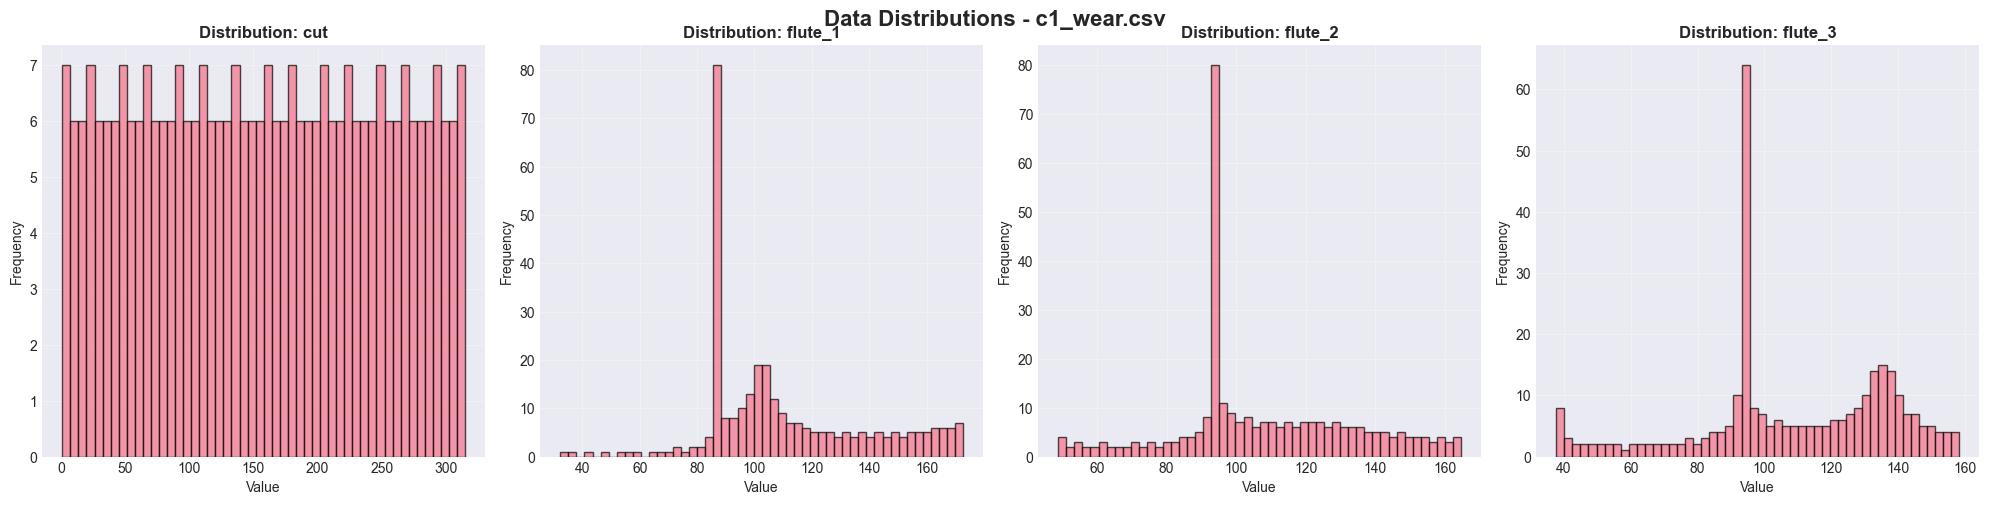

✓ Plotted distributions for 4 numeric columns


In [10]:
# Select first dataset for visualization
if len(all_datasets) > 0:
    first_dataset_name = list(all_datasets.keys())[0]
    df_viz = all_datasets[first_dataset_name]
    
    numeric_cols = df_viz.select_dtypes(include=[np.number]).columns
    
    if len(numeric_cols) > 0:
        # Plot distributions
        n_cols = min(4, len(numeric_cols))
        n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
        axes = axes.flatten() if n_rows > 1 or n_cols > 1 else [axes]
        
        for idx, col in enumerate(numeric_cols[:len(axes)]):
            axes[idx].hist(df_viz[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
            axes[idx].set_title(f'Distribution: {col}', fontsize=12, fontweight='bold')
            axes[idx].set_xlabel('Value')
            axes[idx].set_ylabel('Frequency')
            axes[idx].grid(True, alpha=0.3)
        
        # Hide empty subplots
        for idx in range(len(numeric_cols), len(axes)):
            axes[idx].axis('off')
        
        plt.tight_layout()
        plt.suptitle(f'Data Distributions - {first_dataset_name}', 
                    fontsize=16, fontweight='bold', y=1.001)
        plt.show()
        
        print(f"✓ Plotted distributions for {len(numeric_cols)} numeric columns")

## Step 11: Correlation Analysis
Understand relationships between variables

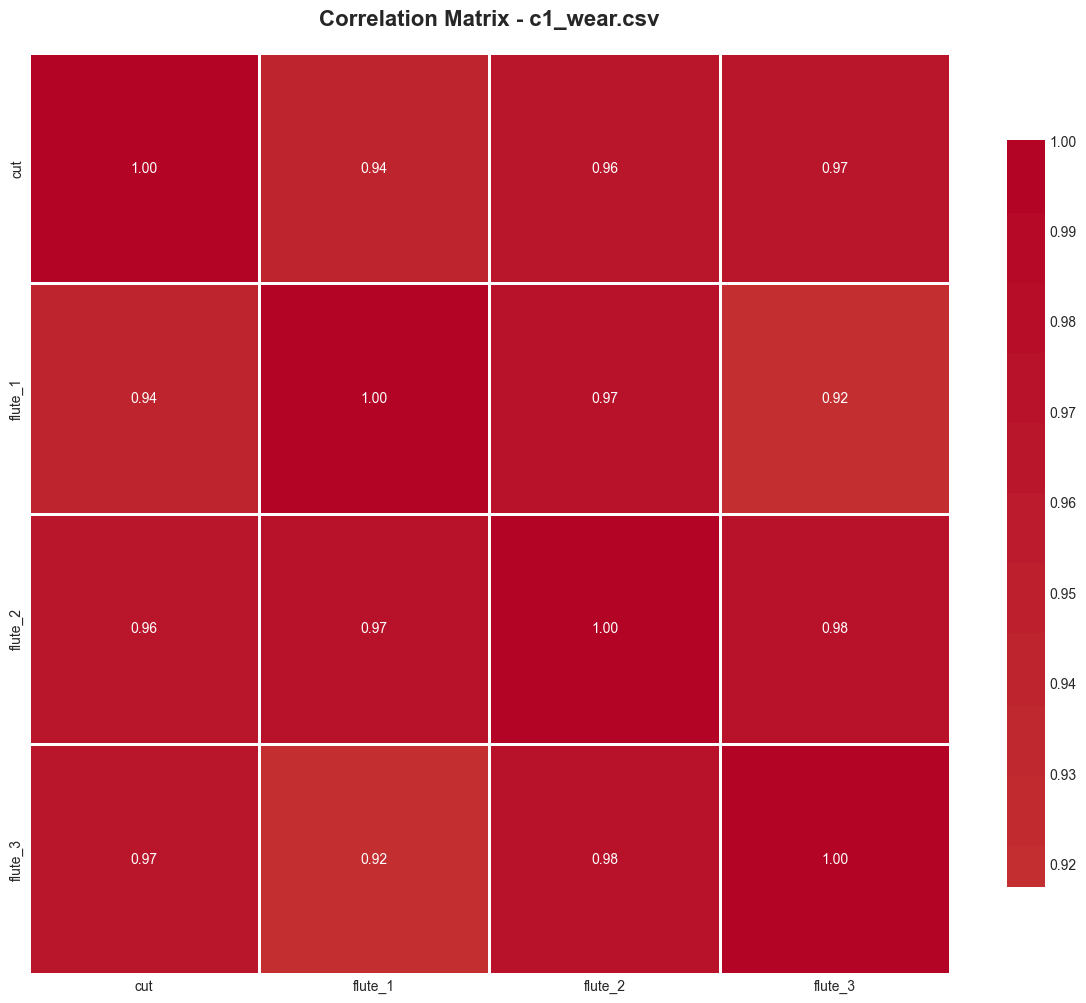


Highly Correlated Features (|correlation| > 0.7):
Feature 1 Feature 2  Correlation
  flute_2   flute_3     0.976000
  flute_1   flute_2     0.973000
      cut   flute_3     0.968000
      cut   flute_2     0.962000
      cut   flute_1     0.944000
  flute_1   flute_3     0.917000


In [11]:
if len(all_datasets) > 0:
    first_dataset_name = list(all_datasets.keys())[0]
    df_corr = all_datasets[first_dataset_name]
    
    numeric_cols = df_corr.select_dtypes(include=[np.number]).columns
    
    if len(numeric_cols) > 1:
        # Calculate correlation matrix
        corr_matrix = df_corr[numeric_cols].corr()
        
        # Plot correlation heatmap
        plt.figure(figsize=(12, 10))
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                   center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
        plt.title(f'Correlation Matrix - {first_dataset_name}', 
                 fontsize=16, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()
        
        # Find highly correlated pairs
        print("\nHighly Correlated Features (|correlation| > 0.7):")
        print("="*80)
        high_corr = []
        for i in range(len(corr_matrix.columns)):
            for j in range(i+1, len(corr_matrix.columns)):
                if abs(corr_matrix.iloc[i, j]) > 0.7:
                    high_corr.append({
                        'Feature 1': corr_matrix.columns[i],
                        'Feature 2': corr_matrix.columns[j],
                        'Correlation': round(corr_matrix.iloc[i, j], 3)
                    })
        
        if high_corr:
            high_corr_df = pd.DataFrame(high_corr)
            high_corr_df = high_corr_df.sort_values('Correlation', 
                                                    key=abs, ascending=False)
            print(high_corr_df.to_string(index=False))
        else:
            print("No highly correlated feature pairs found.")

## Step 12: Time Series Analysis (if applicable)
Analyze temporal patterns in the data

Time-related columns found: []


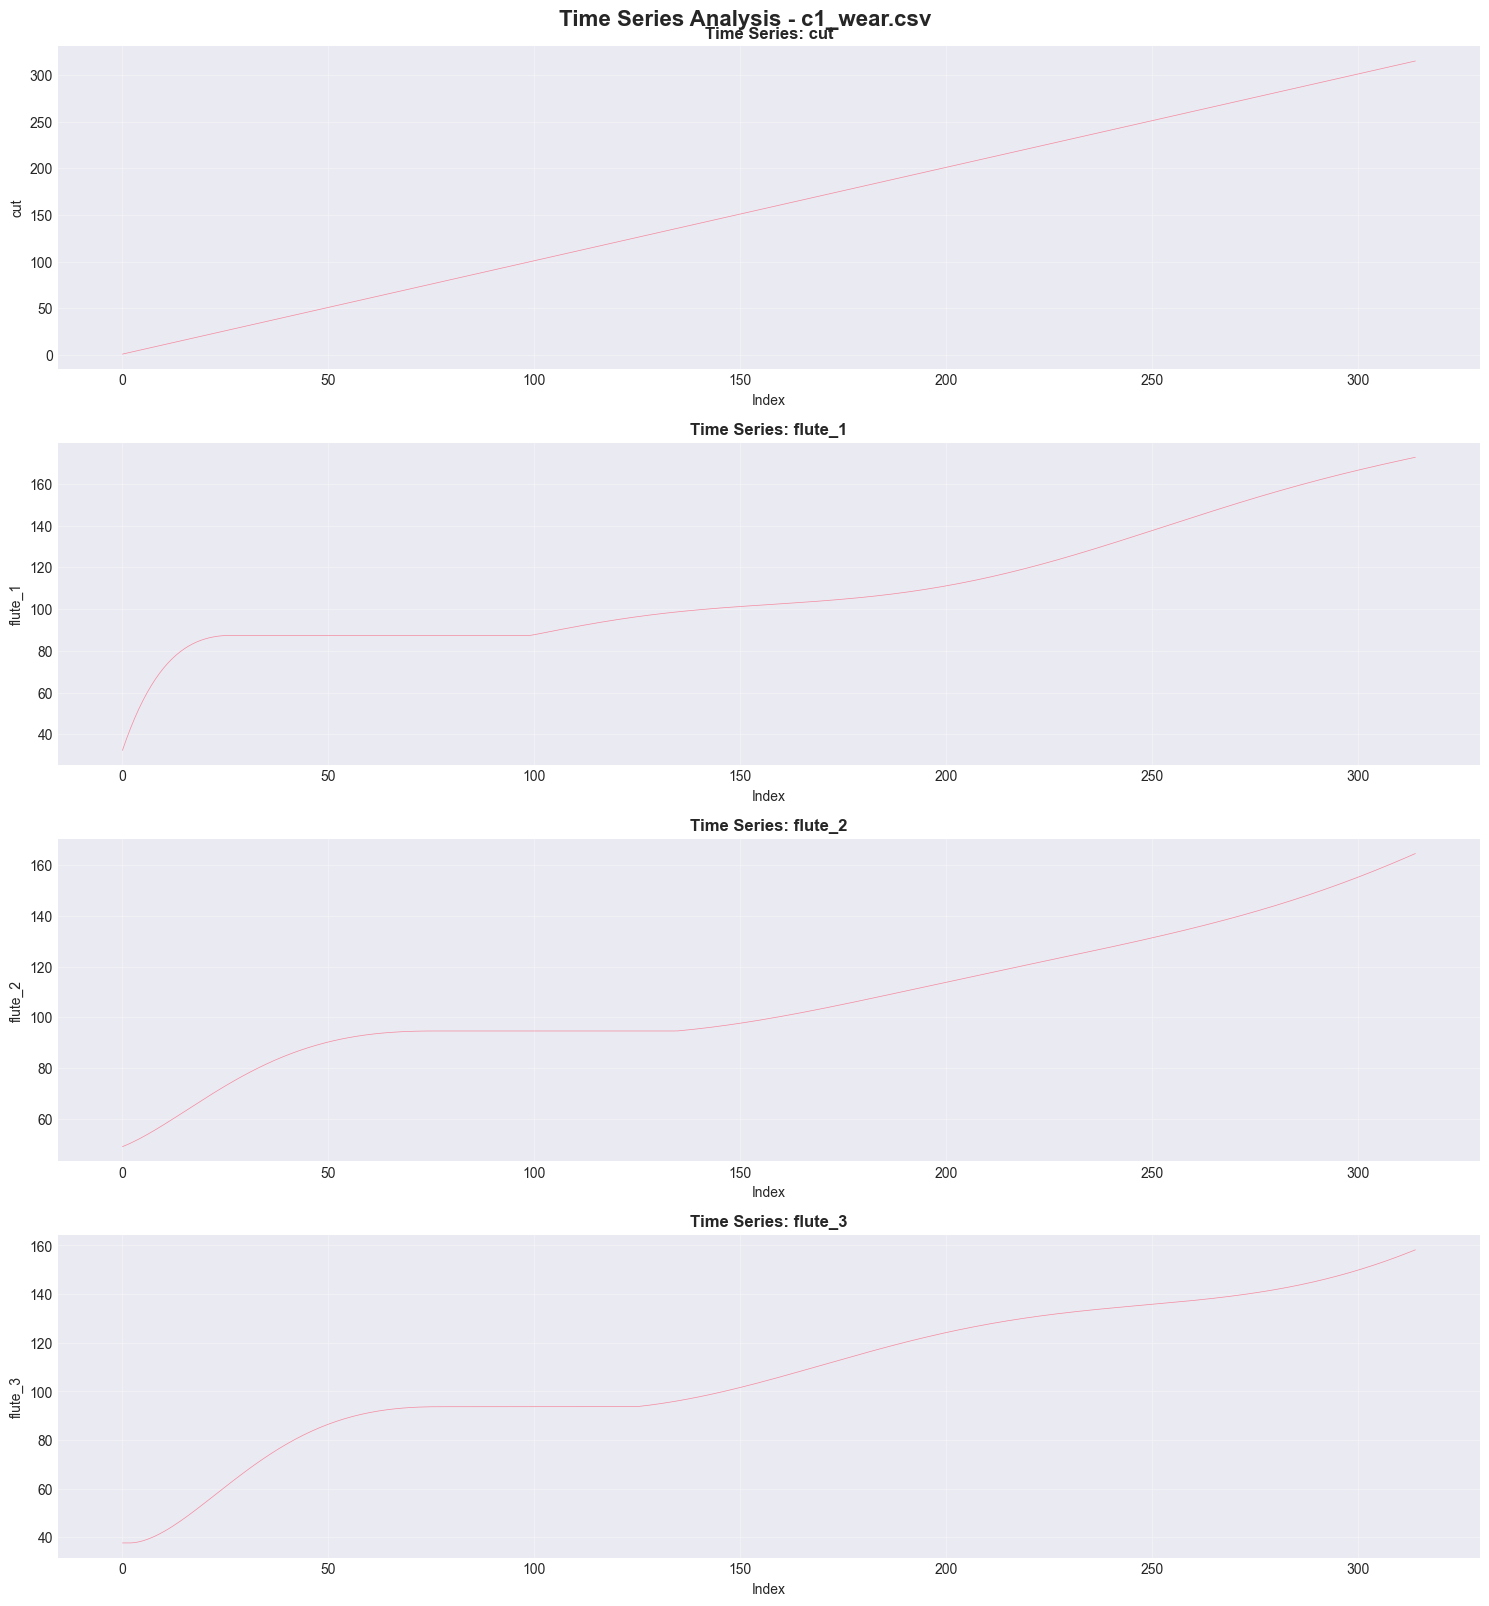

✓ Plotted time series for 4 variables


In [12]:
# Check if data has time-series structure
if len(all_datasets) > 0:
    first_dataset_name = list(all_datasets.keys())[0]
    df_ts = all_datasets[first_dataset_name]
    
    # Look for time-related columns
    time_keywords = ['time', 'timestamp', 'date', 'sample', 'index']
    time_cols = [col for col in df_ts.columns 
                if any(keyword in str(col).lower() for keyword in time_keywords)]
    
    print("Time-related columns found:", time_cols)
    
    # If we have time column and numeric data, plot time series
    numeric_cols = df_ts.select_dtypes(include=[np.number]).columns
    
    if len(numeric_cols) > 0:
        # Create time index if needed
        if len(time_cols) == 0:
            df_ts['Index'] = range(len(df_ts))
            time_col = 'Index'
        else:
            time_col = time_cols[0]
        
        # Plot first few numeric columns over time
        cols_to_plot = numeric_cols[:min(4, len(numeric_cols))]
        
        fig, axes = plt.subplots(len(cols_to_plot), 1, figsize=(15, 4*len(cols_to_plot)))
        if len(cols_to_plot) == 1:
            axes = [axes]
        
        for idx, col in enumerate(cols_to_plot):
            axes[idx].plot(df_ts[time_col], df_ts[col], linewidth=0.5, alpha=0.8)
            axes[idx].set_title(f'Time Series: {col}', fontsize=12, fontweight='bold')
            axes[idx].set_xlabel(time_col)
            axes[idx].set_ylabel(col)
            axes[idx].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.suptitle(f'Time Series Analysis - {first_dataset_name}', 
                    fontsize=16, fontweight='bold', y=1.001)
        plt.show()
        
        print(f"✓ Plotted time series for {len(cols_to_plot)} variables")

## Step 13: Export Summary Report
Save all findings to a text file for your notes

In [13]:
# Create comprehensive summary report
report_lines = []
report_lines.append("="*80)
report_lines.append("PHM CHALLENGE 2010 MILLING DATASET - COMPLETE ANALYSIS REPORT")
report_lines.append("="*80)
report_lines.append(f"\nGenerated: {pd.Timestamp.now()}")
report_lines.append(f"Dataset Path: {DATA_PATH}\n")

report_lines.append("\n" + "="*80)
report_lines.append("1. DATASET OVERVIEW")
report_lines.append("="*80)
report_lines.append(f"Total files analyzed: {len(all_datasets)}")
report_lines.append(f"Total rows: {sum(df.shape[0] for df in all_datasets.values()):,}")
report_lines.append(f"Total memory: {sum(df.memory_usage(deep=True).sum() for df in all_datasets.values())/(1024*1024):.2f} MB")

# Add detailed info for each file
for filename, df in all_datasets.items():
    report_lines.append(f"\n\n{'='*80}")
    report_lines.append(f"FILE: {filename}")
    report_lines.append("="*80)
    report_lines.append(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    report_lines.append(f"\nColumns: {', '.join(df.columns.astype(str))}")
    
    report_lines.append("\nColumn Details:")
    for col in df.columns:
        report_lines.append(f"  - {col}: {df[col].dtype}, {df[col].nunique()} unique values, "
                          f"{df[col].isnull().sum()} missing ({df[col].isnull().sum()/len(df)*100:.1f}%)")
    
    # Add statistical summary
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        report_lines.append("\nStatistical Summary:")
        report_lines.append(str(df[numeric_cols].describe()))

# Save report
report_path = os.path.join(DATA_PATH, 'DATA_EXPLORATION_REPORT.txt')
with open(report_path, 'w', encoding='utf-8') as f:
    f.write('\n'.join(report_lines))

print(f"✓ Report saved to: {report_path}")
print(f"\nReport contains {len(report_lines)} lines of detailed analysis!")

✓ Report saved to: E:\Collaboration Work\With Farooq\phm dataset\PHM Challange 2010 Milling\DATA_EXPLORATION_REPORT.txt

Report contains 28398 lines of detailed analysis!


## Step 14: KEY FINDINGS & NOTES FOR YOUR PUBLICATION

### Write your observations here as you discover them:

1. **Dataset Structure:**
   - Number of experiments/runs:
   - Number of sensors:
   - Sampling rate:
   - Duration of each experiment:

2. **Variables:**
   - Independent variables (controllable):
   - Dependent variables (measured):
   - Target variable (what we're predicting):

3. **Data Quality:**
   - Missing data issues:
   - Outliers:
   - Data preprocessing needed:

4. **Patterns Observed:**
   - Trends:
   - Correlations:
   - Anomalies:

5. **Next Steps for Analysis:**
   - Feature engineering ideas:
   - Modeling approach:
   - Validation strategy:


## Step 15: Save Your Work
Export processed data for further analysis

In [15]:
import os

# Define your desired save location
output_dir = r"F:\phm_rul_reserach\phm data"
os.makedirs(output_dir, exist_ok=True)

print(f"Saving processed data to: {output_dir}")
print("="*80)

# Save each dataset as CSV and pickle for future use
for filename, df in all_datasets.items():
    base_name = os.path.splitext(filename)[0]
    
    # Save as CSV
    csv_path = os.path.join(output_dir, f"{base_name}_processed.csv")
    df.to_csv(csv_path, index=False)
    print(f"✓ Saved: {base_name}_processed.csv")
    
    # Save as pickle (preserves data types)
    pkl_path = os.path.join(output_dir, f"{base_name}_processed.pkl")
    df.to_pickle(pkl_path)
    print(f"✓ Saved: {base_name}_processed.pkl")

print("\n" + "="*80)
print("✓ All data saved successfully!")
print("="*80)


Saving processed data to: F:\phm_rul_reserach\phm data
✓ Saved: c1_wear_processed.csv
✓ Saved: c1_wear_processed.pkl
✓ Saved: c_1_001_processed.csv
✓ Saved: c_1_001_processed.pkl
✓ Saved: c_1_002_processed.csv
✓ Saved: c_1_002_processed.pkl
✓ Saved: c_1_003_processed.csv
✓ Saved: c_1_003_processed.pkl
✓ Saved: c_1_004_processed.csv
✓ Saved: c_1_004_processed.pkl
✓ Saved: c_1_005_processed.csv
✓ Saved: c_1_005_processed.pkl
✓ Saved: c_1_006_processed.csv
✓ Saved: c_1_006_processed.pkl
✓ Saved: c_1_007_processed.csv
✓ Saved: c_1_007_processed.pkl
✓ Saved: c_1_008_processed.csv
✓ Saved: c_1_008_processed.pkl
✓ Saved: c_1_009_processed.csv
✓ Saved: c_1_009_processed.pkl
✓ Saved: c_1_010_processed.csv
✓ Saved: c_1_010_processed.pkl
✓ Saved: c_1_011_processed.csv
✓ Saved: c_1_011_processed.pkl
✓ Saved: c_1_012_processed.csv
✓ Saved: c_1_012_processed.pkl
✓ Saved: c_1_013_processed.csv
✓ Saved: c_1_013_processed.pkl
✓ Saved: c_1_014_processed.csv
✓ Saved: c_1_014_processed.pkl
✓ Saved: c_1_01

---
## 🎯 NEXT STEPS FOR YOUR PUBLICATION

Now that you understand the data completely, here are the next phases:

### Phase 2: Feature Engineering
- Extract time-domain features (mean, std, RMS, peak, etc.)
- Extract frequency-domain features (FFT, spectral analysis)
- Create degradation indicators
- Build health indices

### Phase 3: Exploratory Data Analysis
- Analyze tool wear progression
- Compare different operating conditions
- Statistical hypothesis testing
- Advanced visualizations

### Phase 4: Machine Learning
- Select appropriate algorithms
- Train predictive models
- Validate and test
- Compare with baseline methods

### Phase 5: Publication Writing
- Literature review
- Methodology documentation
- Results and discussion
- Paper writing

---
**Remember**: Understanding your data deeply is the foundation of good research. Take notes, ask questions, and explore thoroughly!

**You've got this! 💪**